In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text

# Load the dataset
id3_df = pd.read_csv("ID3_PlayTennis.csv")

# Features and target
X = id3_df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = id3_df['PlayTennis']

# Convert categorical features to numeric using one-hot encoding
X_encoded = pd.get_dummies(X)

# Build Decision Tree using ID3 criterion (Information Gain = 'entropy')
id3_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
id3_tree.fit(X_encoded, y)

# Display the tree structure
tree_rules = export_text(id3_tree, feature_names=list(X_encoded.columns))
print(tree_rules)

|--- Outlook_Overcast <= 0.50
|   |--- Humidity_Normal <= 0.50
|   |   |--- Outlook_Rain <= 0.50
|   |   |   |--- class: No
|   |   |--- Outlook_Rain >  0.50
|   |   |   |--- Wind_Strong <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- Wind_Strong >  0.50
|   |   |   |   |--- class: No
|   |--- Humidity_Normal >  0.50
|   |   |--- Wind_Strong <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Wind_Strong >  0.50
|   |   |   |--- Outlook_Sunny <= 0.50
|   |   |   |   |--- class: No
|   |   |   |--- Outlook_Sunny >  0.50
|   |   |   |   |--- class: Yes
|--- Outlook_Overcast >  0.50
|   |--- class: Yes



In [ ]:
import graphviz
from sklearn.tree import export_graphviz

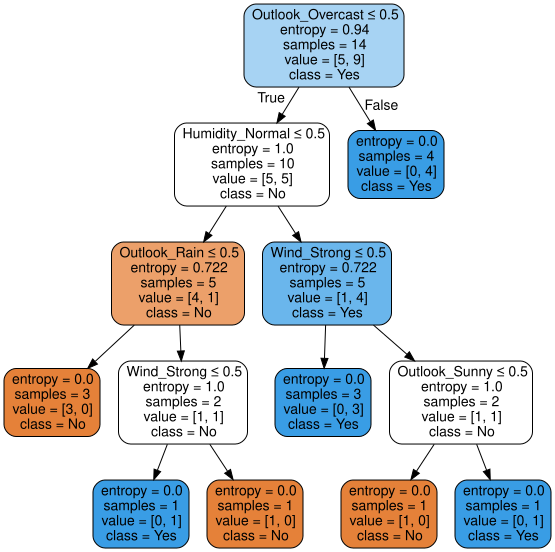

In [ ]:
# Visualize the Decision Tree
dot_data = export_graphviz(id3_tree, out_file=None,
                          feature_names=X_encoded.columns,
                          class_names=id3_tree.classes_,
                          filled=True, rounded=True,
                          special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
# Make predictions on the training data
y_pred = id3_tree.predict(X_encoded)

# Calculate and display the Confusion Matrix
conf_matrix = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate and display the Accuracy Score
accuracy = accuracy_score(y, y_pred)
print(f"\nAccuracy Score: {accuracy:.2f}")

# Generate and display the Classification Report
class_report = classification_report(y, y_pred)
print("\nClassification Report:")
print(class_report)

Confusion Matrix:
[[5 0]
 [0 9]]

Accuracy Score: 1.00

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



DT for Churn Prediction

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text

# Load the dataset
cart_df = pd.read_csv("CART_CustomerChurn.csv")

# Features and target
X = cart_df[['Age', 'Salary', 'PurchasedProduct']]
y = cart_df['Churn']

# Convert categorical features to numeric using one-hot encoding
X_encoded = pd.get_dummies(X)

# Build Decision Tree using CART criterion (Gini Index = 'gini')
cart_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_tree.fit(X_encoded, y)

# Display the tree structure
tree_rules = export_text(cart_tree, feature_names=list(X_encoded.columns))
print(tree_rules)

|--- Salary <= 77.50
|   |--- class: No
|--- Salary >  77.50
|   |--- Salary <= 110.00
|   |   |--- PurchasedProduct_B <= 0.50
|   |   |   |--- class: No
|   |   |--- PurchasedProduct_B >  0.50
|   |   |   |--- class: Yes
|   |--- Salary >  110.00
|   |   |--- class: Yes



In [ ]:
import graphviz
from sklearn.tree import export_graphviz
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

### Visualizing the CART Decision Tree

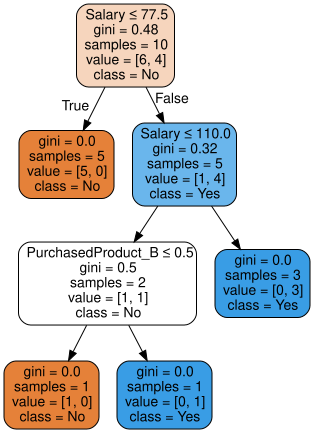

In [ ]:
# Visualize the Decision Tree
dot_data = export_graphviz(cart_tree, out_file=None,
                          feature_names=X_encoded.columns,
                          class_names=cart_tree.classes_,
                          filled=True, rounded=True,
                          special_characters=True)
graph = graphviz.Source(dot_data)
graph

### Classification Report for CART Decision Tree

In [ ]:
# Make predictions on the training data
y_pred_cart = cart_tree.predict(X_encoded)

# Calculate and display the Confusion Matrix
conf_matrix_cart = confusion_matrix(y, y_pred_cart)
print("Confusion Matrix:")
print(conf_matrix_cart)

# Calculate and display the Accuracy Score
accuracy_cart = accuracy_score(y, y_pred_cart)
print(f"\nAccuracy Score: {accuracy_cart:.2f}")

# Generate and display the Classification Report
class_report_cart = classification_report(y, y_pred_cart)
print("\nClassification Report:")
print(class_report_cart)

Confusion Matrix:
[[6 0]
 [0 4]]

Accuracy Score: 1.00

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         6
         Yes       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

